# (B) 1.

**Import your package in the documentation notebook**

In [2]:
# Import package here
from nv import *

# (B) 2.

**Describe your generative model**

We will model the observed data as an image of flouresence from a single NV center measured at a fixed microwave frequency $f_{MW}$. Each data point is recorded at a pixel in a 2D array, such that our data is:
$$
D = \{y_{ij}\}
$$
where $y_{ij}$ is the measured flourescene rate in kCounts/s at pixel $(i, j)$. The goal, from this data, is to infer the parameters of a magnetic dipole from this image. 

For the purpose of this preliminary model, we will only consider the following parameters: 
- single magnetic dipole
- known NV axis $\mathbf{\hat{n}}$
- Lorentzian fluorescence dip as a function of detuning
- constant background floresence
- independent Gaussian pixel noise

**Parameters:** For the full parameter vector, consider:

$$
\theta = \left(x_d, y_d, z_d, m_x, m_y, m_z, \beta_0, C, \Gamma, \delta_0, \sigma\right).
$$

Where:

- $(x_d, y_d, z_d)$: dipole position
- $(m_x, m_y, m_z)$: dipole moment components
- $\beta_0$: background offset
- $C$: fluorescence dip contrast
- $\Gamma$: resonance linewidth parameter
- $\delta_0$: global detuning offset
- $\sigma$: standard deviation of the pixel noise

What we will have as input from the image data is the pixel coordinate, i.e. the relative position of the NV center with respect to the NV center. For the defined coordinates $(i, j)$, the full scan coordiante is then
$$
\mathbf{r_{ij}} = (x_{ij}, y_{ij}, z_{NV})
$$
Where $z_{NV}$ is the height of the imaging plane. 

**Dipole B-Field**: We model the magnet as a simple point dipole located at 
$$
\mathbf{r_d} = (x_d, y_d, z_d)
$$
with dipole moment

$$
\mathbf{m} = (m_x, m_y, m_z)
$$
This allows us to define
$$
\mathbf R_{ij} = \mathbf r_{ij} - \mathbf r_d,
\qquad
R_{ij} = \|\mathbf R_{ij}\|,
\qquad
\hat{\mathbf R}_{ij} = \frac{\mathbf R_{ij}}{R_{ij}}.
$$
As the parameter for distance and direction of the displacement of the NV from the dipole. Then, we know that for any given pixel $(i, j)$, the dipole field at that pixel is: 
$$
\mathbf B_{ij}(\theta) = \frac{\mu_0}{4\pi R_{ij}^3} \left[3(\mathbf m \cdot \hat{\mathbf R}_{ij}) \hat{\mathbf R}_{ij} - \mathbf m \right].
$$
Finally, if we assume that the NV orientation is known, then the relevant field component which will impact the spin transition of the NV center is: 
$$
B_{\parallel,ij}(\theta) = \mathbf B_{ij}(\theta) \cdot \hat{\mathbf n}.
$$

**Resonance model:** We are sending in a known, fixed microwave freqeuncy to the system. What we then care about is the detuning between this microwave field and where the NV resonance is. We apply a known fixed microwave frequency $f_{mw}$ to the NV center. The resonance condition is determined by the detuning between this drive frequency and the local NV transition frequency, which depends on the magnetic field projected along the NV axis. This may be modeled as:
$$
f_{NV, ij}(\theta) = D \pm \gamma B_{\parallel ,ij}(\theta)
$$
Where D is the zero field splitting and $\gamma$ is the known NV gyromagnetic factor. The detuning from resonance is thus:
$$
\Delta_{ij}(\theta) = f_{MW} - f_{NV,ij} = f_{MW} - (D \pm \gamma B_{\parallel ,ij}(\theta))
$$

and resonance occurs when $\Delta_{ij}(\theta) \approx 0$, i.e when the local projected magnetic field shifts the NV transition into resonance with the applied microwave tone. 

The dip itself then can be modeled using a Lorentzian line shape. There will be some global background florecense, as well as a contrast parameter $C$ which is intrinsic to the NV center, and will be known. Typically, $C$ is in the range of 25%. Let us then define our signal as: 
$$
\mu_{ij}(\theta) = \beta_0\left[1 - C \frac{1}{1 + \left( \frac{\Delta_{ij}(\theta)}{\Gamma} \right)^2} \right]
$$
Which means the flourecence will be lowest when $\Delta_{ij}$ is appraoching zero, which will produce the dark line that we see on the contour!

**Likelyhood:** Now for the likelyhood, we model each observed pixel as independent gaussian random variables:
$$
y_{ij} \mid \theta \sim \mathcal N\!\left(\mu_{ij}(\theta), \sigma^2\right).
$$
such that the likelyhood for the entire image is
$$
p(D \mid \theta) = \prod_{i,j} \mathcal{N} \!\left(y_{ij} \mid \mu_{ij}(\theta), \sigma^2\right).
$$
Which, for right now, we aknowledge is an aproximation for the true counting statistics. But because each pixel is an averaged flouresence, the noise should be approximately gaussian. 

**Priors:** Now, in order to complete our model, we need to assign priors to each of the unknown parameters. 

For the dipole position, we say that the dipole may appear anywhere within the region of the image with equal probability: 
$$
x_d \sim \mathrm{Uniform}(x_{\min}, x_{\max}),
\qquad
y_d \sim \mathrm{Uniform}(y_{\min}, y_{\max}),
\qquad
z_d \sim \mathrm{Uniform}(z_{\min}, z_{\max}).
$$

**UPDATE:** For the dipole itself, it is typically magnetized experimentally by applying an external field approximately along the z-axis. Thus, we should use a prior that favors a dipole moment that points roughly along the z-axis, but allows for imperfect alignment in x and y. Now, this turned out to be a rather challenging task. If we allow the vector to vary in all three dimensions, like this:
$$
m_x \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_y \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_z \sim \mathcal{N}(m_{z,0}, s_z^2)
$$
the problem becomes very unconstrained. Allowing the dipole direction to vary arbitrarily introduces strong degeneracies with the dipole depth and magnitude. We then thought about using a Von Mises prior on the dipole, to solve for the spherical coordinates in a parameterized approach. However, it quickly became apparent that this approach also diverges. I beleive this is because when the azimuthal angle is close to zero for a dipole expected to be oriented in $+z$, there forms a symmetry in which any angle of $\theta$ represents a nearly identical solution. This essentially creates a flat prior with no information, or a free variable, and the solver had a very difficult time handling it.  

So, I then tried to solve exclusively for small variations around a dipole in $+z$. To do this, Let $\mathbf m_{\mathrm{guess}}$ denote our initial guess for the dipole direction. We normalize it to obtain
$$
\hat{\mathbf u}_0 = \frac{\mathbf m_{\mathrm{guess}}}{\|\mathbf m_{\mathrm{guess}}\|}
$$
We then construct two unit vectors $\hat{\mathbf e}_1 and \hat{\mathbf e}_2$ such that
$$
\hat{\mathbf e}_1 \perp \hat{\mathbf u}_0, \qquad
\hat{\mathbf e}_2 \perp \hat{\mathbf u}_0, \qquad
\hat{\mathbf e}_1 \perp \hat{\mathbf e}_2.
$$
Thus, $\{\hat{\mathbf u}_0,\hat{\mathbf e}_1,\hat{\mathbf e}_2\}$ forms an orthonormal basis, with $\hat{\mathbf e}_1$ and $\hat{\mathbf e}_2$ spanning the tangent plane to the unit sphere at $\hat{\mathbf u}_0$.  

We can then use two local coordinates $\alpha_1$ and $\alpha_2$:
$$
\mathbf v = \hat{\mathbf u}_0 + \alpha_1 \hat{\mathbf e}_1 + \alpha_2 \hat{\mathbf e}_2
$$
describe tilt within the local tangent plane. For these priors, we choose 
$$
\alpha_1 \sim \mathcal N(0,\sigma_\alpha^2), \qquad
\alpha_2 \sim \mathcal N(0,\sigma_\alpha^2),
$$
which shows that we are confident the variable is likely around zero, but gives it a chance to deviate at small angles. From this data, we can then back out the exact components of the mangetic dipole after the sampling is done. 

For the magnitude of the magnetic dipole, we say:
$$
\log m_{\mathrm{mag}} \sim \mathcal N(\log m_0,\sigma_m^2),
\qquad
m_{\mathrm{mag}} = e^{\log m_{\mathrm{mag}}},
$$
To account for the fact that the magnetic moment is extremely small. To help with divergences, we deal with the log form first, and then convert it later, so that we can finally pull out the full dipole info:
$$
\mathbf m = m_{\mathrm{mag}} \hat{\mathbf m}.
$$

For the background, the baseline intensity has a rough expected scale, which can be determined emperically from the images or prior scans with the NV center. For this reason, we center the prior at this value with a normal distribution:
$$
\beta_0 \sim \mathcal{N}(\bar{y}, s_{\beta_0}^2)
$$

For the remaining parameters dip contrast, linewidth, and noise standard deviation, we know we need to enforce positivity when we have a generally known scale for the parameter. For this case, we use exponential parameters: 
$$
\Gamma \sim \text{Exponential}(\lambda_\Gamma), 
\qquad
\sigma \sim \text{Exponential}(\lambda_\sigma), 
$$

As well as the contrast $C$ for the system, which we know is a value bounded by $[0, 1]$. With this information we use a Beta prior:
$$
C \sim \text{Beta}(\alpha_C, \beta_C)
$$

Now we may finally think about the joint distribution, which may be written as: 
$$
p(\theta, D) = p(\theta)\prod_{i,j} p(y_{ij}\mid \theta)
$$

with

$$
p(\theta) =
p(x_d)p(y_d)p(z_d)p(m_x)p(m_y)p(m_z)
p(\beta_0)p(C)p(\Gamma)p(\delta_0)p(\sigma),
$$

and 

$$
p(y_{ij}\mid \theta) = \mathcal N\!\left(y_{ij}\mid \mu_{ij}(\theta), \sigma^2\right)
$$

So that the posterior distribution is:

$$
p(\theta \mid D)
\propto
p(D\mid \theta)\,p(\theta).
$$

Right now, we are accounting for the noise with a standard deviation $\sigma$ which absorbs photon counting, detector noise, fluorescence fluctuations, etc. 

# (B) 3.

**Simulate some data using your generative model**

For the simulation, we absorb constants for ease of coding and display. There should technically be a $\mu_0/(4\pi)$ in the dipole, and the gyromagnetic ratio for an electron should be used when determining $\Delta$. This will be incorporated when we implenent the model for real, right now I mostly care about the shape. 

I'm aiming to recreate data as seen in the image here, something along these lines:

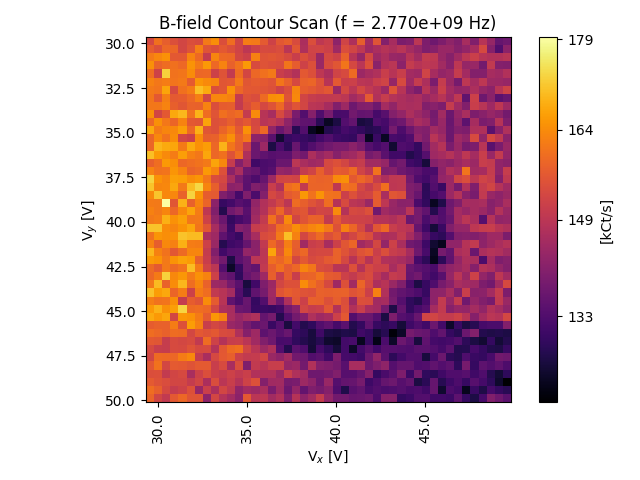

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ---------------------------------------
# Define some set parameters for the scan
# ---------------------------------------

n_pix = 45
vx = np.linspace(30.0, 50.0, n_pix)
vy = np.linspace(30.0, 50.0, n_pix)

VX, VY = np.meshgrid(vx, vy)

# ---------------------------------------
# We have a known volt -> um conversion
# ---------------------------------------
volt_to_m = 0.02e-6
X = VX * volt_to_m
Y = VY * volt_to_m

# ---------------------------------------
# Our third dimension will be the image data
# ---------------------------------------
delta_z_step = 0.03e-6   # 30 nm

Z1 = np.zeros_like(X)
Z2 = np.zeros_like(X) + delta_z_step
Z3 = np.zeros_like(X) + 2 * delta_z_step

In [3]:
MU0 = 1.25663706127e-6 # N/A^2 = T m / A
MU0_OVER_4PI = MU0 / (4 * np.pi)

def dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec):
    """
    Will compute the magnetic field from a dipole
    on a 2D grid

    Input
    -----
    X, Y, Z: 2D arrays representing the observation coordinates
    x_d, y_d, z_d: float: dipole position
    m_vec : array of length 3: dipole moment vector

    Returns
    -------
    Bx, By, Bz : 2D arrays, magnetic field components
    
    """
    mx, my, mz = m_vec

    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R = np.sqrt(R2)

    # include a safety cutoff value to top R^3, R^5 terms from blowing up
    lim = 1e-30
    R = np.maximum(R, lim)

    m_dot_R = mx*Rx + my*Ry + mz*Rz

    Bx = MU0_OVER_4PI * (3.0 * m_dot_R * Rx / R**5 - mx / R**3)
    By = MU0_OVER_4PI * (3.0 * m_dot_R * Ry / R**5 - my / R**3)
    Bz = MU0_OVER_4PI * (3.0 * m_dot_R * Rz / R**5 - mz / R**3)

    return Bx, By, Bz # will now be in Tesla

In [4]:
GAMMA_NV_MHZ_PER_T = 28024.95138616912 # MHz/T
D_NV_MHZ = 2870.0 # MHz

def mean_fluorescence(
    X, Y, Z, 
    x_d, y_d, z_d, 
    m_vec, 
    n_vec, 
    beta0, 
    C, 
    Gamma, 
    f_mw,
    branch_sign=-1
):
    """
    Computes the noiseless fluorescence image for a fixed microwave tone.

    Input
    ----------
    X, Y, Z : 2D ndarray
        Observation coordinates of the scan grid, in METERS

    x_d, y_d, z_d : float
        Cartesian coordinates of the dipole position, in METERS.

    m_vec : array of shape (3,)
        Dipole moment vector [m_x, m_y, m_z], in A m^2.

    n_vec : array-like of shape (3,)
        Unit vector giving the NV orientation axis.

    beta0 : float
        Background fluorescence level, in kc/s.

    C : float
        ODMR contrast parameter. Dimensionless, between 0, 1

    Gamma : float
        Lorentzian linewidth parameter, in MHz.

    f_mw : float
        Applied microwave frequency, in MHz.

    branch_sign : int, optional
        Chooses which ODMR branch is being driven.
        Use -1 for the lower-frequency branch and +1 for the upper-frequency
        branch.

    Returns
    -------
    mu : 2D ndarray
        Data for fluorescence image, in kc/s.

    B_par : 2D ndarray
        Magnetic field component projected along the NV axis, in TESLA.

    Delta : 2D ndarray
        Frequency detuning f_mw - f_nv at each pixel, in MHz.
    """

    Bx, By, Bz = dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec)

    nx, ny, nz = n_vec
    B_par = nx*Bx + ny*By + nz*Bz

    f_nv = D_NV_MHZ + branch_sign * GAMMA_NV_MHZ_PER_T * B_par
    Delta = f_mw - f_nv

    lorentzian = 1.0 / (1.0 + (Delta/Gamma)**2)
    mu = beta0 * (1.0 - C*lorentzian)

    return mu, B_par, Delta

In [5]:
# ---------------------------------------
# Choose the TRUE parameter values
# ---------------------------------------

UM = 1e-6
# dipole position, arbitrary position
x_d_true = 0.80 * UM
y_d_true = 0.81 * UM
z_d_true = -0.078 * UM

# Dipole moment (mostly z with small tilt)
m_dir = np.array([0.15, -0.08, 1.00])
m_dir = m_dir / np.linalg.norm(m_dir)

m_mag_true = 3e-16 # A m^2 
m_vec_true = m_mag_true * m_dir

# Our known NV axis
n_vec_true = np.array([0.0, 0.0, 1.00])

# Global Background
beta0_true = 145.0 #kc/s

# Lorentzian dip params
C_true = 0.30
Gamma_true = 40.0 # same freq units as delta

# known mw input tone
f_mw_true = 2770.0 # MHz

# Which ODMR branch are we driving?
branch_sign_true = -1 # we almost always drive lower branch

# Noise level?
sigma_true = 2.5 #kc/s

**UPDATE:** The dipole magnitude and the z distance to the NV are HIGHLY coorelated - changing one is essentially equivalent to changing the other. Because of this, almost all attempts to sample a model with both of them free from a single image never converged. In order to combat this, we change the input to accept multiple images, or multiple 'slices' from different z-heights. Now, we can use multiple likeleyhoods to improve our chances of converging. The dipole has to stay constant, but now with height changing, we can better isolate the compnents of the data due to height vs dipole magnitude. 

In [6]:
# ---------------------------------------------
# Simulate the noiseless image from true values
# ---------------------------------------------

mu_true_1, Bpar_true_1, Delta_true_1 = mean_fluorescence(
    X, Y, Z1,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

mu_true_2, Bpar_true_2, Delta_true_2 = mean_fluorescence(
    X, Y, Z2,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

mu_true_3, Bpar_true_3, Delta_true_3 = mean_fluorescence(
    X, Y, Z3,
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true,
    beta0_true,
    C_true,
    Gamma_true,
    f_mw_true,
    branch_sign_true
)

# And now draw noisy observations
rng = np.random.default_rng(1)

y_sim_1 = rng.normal(loc=mu_true_1, scale=sigma_true, size=mu_true_1.shape)
y_sim_2 = rng.normal(loc=mu_true_2, scale=sigma_true, size=mu_true_2.shape)
y_sim_3 = rng.normal(loc=mu_true_3, scale=sigma_true, size=mu_true_3.shape)

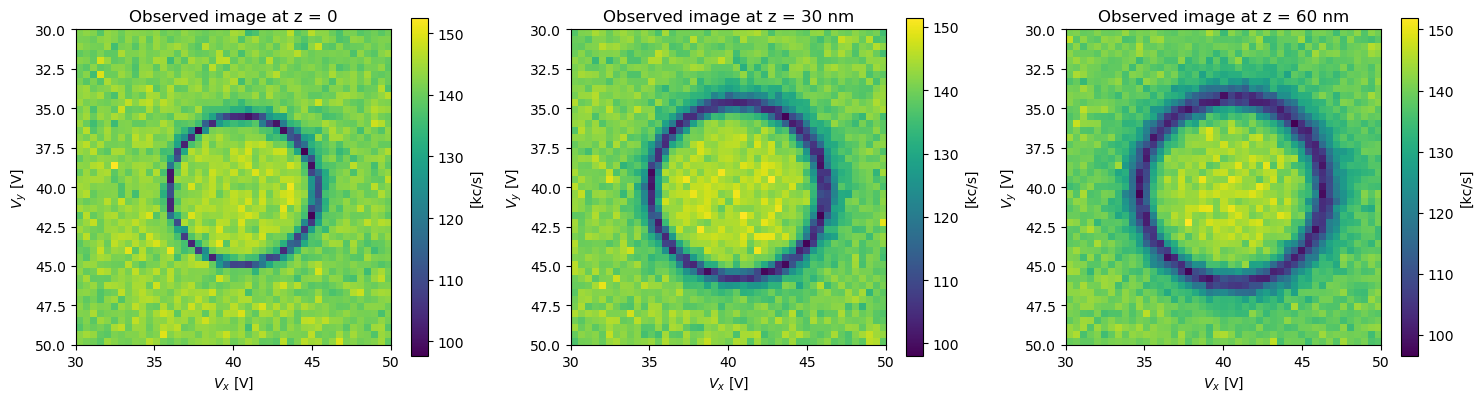

In [7]:
# -----------------------
# Plot our simulated data
# -----------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(y_sim_1, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[0].set_title("Observed image at z = 0")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")
plt.colorbar(im1, ax=axes[0], label="[kc/s]")

im2 = axes[1].imshow(y_sim_2, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[1].set_title(f"Observed image at z = 30 nm")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")
plt.colorbar(im2, ax=axes[1], label="[kc/s]")

im3 = axes[2].imshow(y_sim_3, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[2].set_title(f"Observed image at z = 60 nm")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")
plt.colorbar(im3, ax=axes[2], label="[kc/s]")

plt.tight_layout()
plt.show()

**REMEMBER**  
- Scan coordinates converted from volts to **meters**
- Dipole position in **meters**
- Dipole moment in **$A*m^2$**  
- Fixed mw frequency in **MHZ**  

# (B) 4.

**Infer parameters from your simulated data**

In [8]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

Lets make our functions pytensor compatible so we can use them with PyMC:

In [9]:
MU0 = 1.25663706127e-6 # T m / A
MU0_OVER_4PI = MU0 / (4.0 * np.pi) # ~1e-7 T m / A

def dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z):
    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R2 = pt.maximum(R2, 1e-30)
    R = pt.sqrt(R2)

    m_dot_R = m_x * Rx + m_y * Ry + m_z * Rz

    Bx = MU0_OVER_4PI * (3.0 * m_dot_R * Rx / R**5 - m_x / R**3)
    By = MU0_OVER_4PI * (3.0 * m_dot_R * Ry / R**5 - m_y / R**3)
    Bz = MU0_OVER_4PI * (3.0 * m_dot_R * Rz / R**5 - m_z / R**3)

    return Bx, By, Bz

In [10]:
D_NV_MHZ = 2870.0 # zero-field splitting [MHz]
GAMMA_NV_MHZ_PER_T = 28024.951386 # NV gyromagnetic ratio [MHz/T]

def mean_fluorescence_pt(X, Y, Z, x_d, y_d, z_d,
                         m_x, m_y, m_z,
                         beta0, C, Gamma, f_mw, n_vec,
                        branch_sign=-1):
    
    Bx, By, Bz = dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z)

    nx, ny, nz = n_vec
    B_par = nx * Bx + ny * By + nz * Bz

    f_nv = D_NV_MHZ + branch_sign * GAMMA_NV_MHZ_PER_T * B_par
    Delta = f_mw - f_nv
    
    L = 1.0 / (1.0 + (Delta / Gamma)**2)
    mu = beta0 * (1.0 - C * L)

    return mu, B_par, Delta

**Description of dipole model HERE**

In [11]:
# Use grahm schmidt: use a starting vector t, then subtract off its projection in order 
# to get a vector perpendicular to your guess. Then, use the cross product to find a 
# second vector perpendicular to the first two. 
def make_local_basis(m_guess):
    u0 = np.asarray(m_guess, dtype=float)
    u0 = u0 / np.linalg.norm(u0)

    t = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(t, u0)) > 0.9:
        t = np.array([1.0, 0.0, 0.0])

    e1 = t - np.dot(t, u0) * u0
    e1 = e1 / np.linalg.norm(e1)

    e2 = np.cross(u0, e1)
    e2 = e2 / np.linalg.norm(e2)

    return u0, e1, e2

In [12]:
m_guess = np.array([0.0, 0.0, 1.0])
u0, e1, e2 = make_local_basis(m_guess)

In [13]:
with pm.Model() as nv_model:

    X_data = pm.Data("X_data", X.astype("float64"))
    Y_data = pm.Data("Y_data", Y.astype("float64"))

    Z1_data = pm.Data("Z1_data", Z1.astype("float64"))
    Z2_data = pm.Data("Z2_data", Z2.astype("float64"))
    Z3_data = pm.Data("Z3_data", Z3.astype("float64"))

    y1_sim = pm.Data("y1_sim", y_sim_1.astype("float64"))
    y2_sim = pm.Data("y2_sim", y_sim_2.astype("float64"))
    y3_sim = pm.Data("y3_sim", y_sim_3.astype("float64"))

    # geometry
    z_d_um = pm.Normal("z_d_um", mu=0.078, sigma=0.05)
    x_d_um = pm.Uniform("x_d_um", lower=0.55, upper=1.05)
    y_d_um = pm.Uniform("y_d_um", lower=0.55, upper=1.05)

    z_d = -z_d_um * 1e-6
    x_d = x_d_um * 1e-6
    y_d = y_d_um * 1e-6

    # dipole magnitude
    log_m_mag = pm.Normal("log_m_mag", mu=np.log(3e-16), sigma=0.5)
    m_mag = pt.exp(log_m_mag)

    # local coordinate system around guessed direction
    alpha1 = pm.Normal("alpha1", mu=0.0, sigma=0.03)
    alpha2 = pm.Normal("alpha2", mu=0.0, sigma=0.03)

    # we now have two linear parameters which describe variation around our guess
    vx = u0[0] + alpha1 * e1[0] + alpha2 * e2[0]
    vy = u0[1] + alpha1 * e1[1] + alpha2 * e2[1]
    vz = u0[2] + alpha1 * e1[2] + alpha2 * e2[2]

    norm = pt.sqrt(vx**2 + vy**2 + vz**2)

    mx_hat = vx / norm
    my_hat = vy / norm
    mz_hat = vz / norm

    m_x = m_mag * mx_hat
    m_y = m_mag * my_hat
    m_z = m_mag * mz_hat

    beta0 = pm.Normal("beta0", mu=float(np.mean([y_sim_1.mean(), y_sim_2.mean(), y_sim_3.mean()])), sigma=10.0)
    C = pm.Beta("C", alpha=2.0, beta=5.0)
    Gamma = pm.Exponential("Gamma", lam=1/40.0)

    mu_model_1, _, _ = mean_fluorescence_pt(
        X_data, Y_data, Z1_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    mu_model_2, _, _ = mean_fluorescence_pt(
        X_data, Y_data, Z2_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    mu_model_3, _, _ = mean_fluorescence_pt(
        X_data, Y_data, Z3_data,
        x_d, y_d, z_d,
        m_x, m_y, m_z,
        beta0, C, Gamma, f_mw_true,
        n_vec_true,
        branch_sign=branch_sign_true
    )

    pm.Normal("y1_like", mu=mu_model_1, sigma=sigma_true, observed=y1_sim)
    pm.Normal("y2_like", mu=mu_model_2, sigma=sigma_true, observed=y2_sim)
    pm.Normal("y3_like", mu=mu_model_3, sigma=sigma_true, observed=y3_sim)

In [14]:
with nv_model:
    nv_samples = pm.sample(
        tune=2000,
        draws=2000,
        chains=4,
        init="adapt_diag",
        target_accept=0.95
    )

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [z_d_um, x_d_um, y_d_um, log_m_mag, alpha1, alpha2, beta0, C, Gamma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 86 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_d_um,0.078040,0.000083,0.077882,0.078196,0.000001,8.984563e-07,6085.727496,5729.319084,1.000429
x_d_um,0.800330,0.000343,0.799686,0.800957,0.000005,3.951405e-06,5151.482008,4959.861620,0.999842
y_d_um,0.810352,0.000349,0.809702,0.811032,0.000005,4.388350e-06,5065.587345,4333.593156,1.001081
log_m_mag,-35.740459,0.002064,-35.744307,-35.736566,0.000025,2.284917e-05,6654.347340,5062.708317,1.000448
alpha1,0.144527,0.004583,0.135639,0.152677,0.000064,5.322868e-05,5139.139553,5078.242105,0.999993
alpha2,-0.084911,0.004571,-0.093651,-0.076202,0.000064,5.695315e-05,5084.473326,4760.049783,1.001090
beta0,145.014595,0.060181,144.901696,145.131893,0.000763,6.688438e-04,6207.076841,5554.573231,1.000132
C,0.298363,0.001207,0.296050,0.300619,0.000014,1.431426e-05,7457.700230,5084.990414,1.000221
Gamma,40.342796,0.275263,39.831981,40.852319,0.003583,3.157199e-03,5897.794277,5238.881868,0.999879


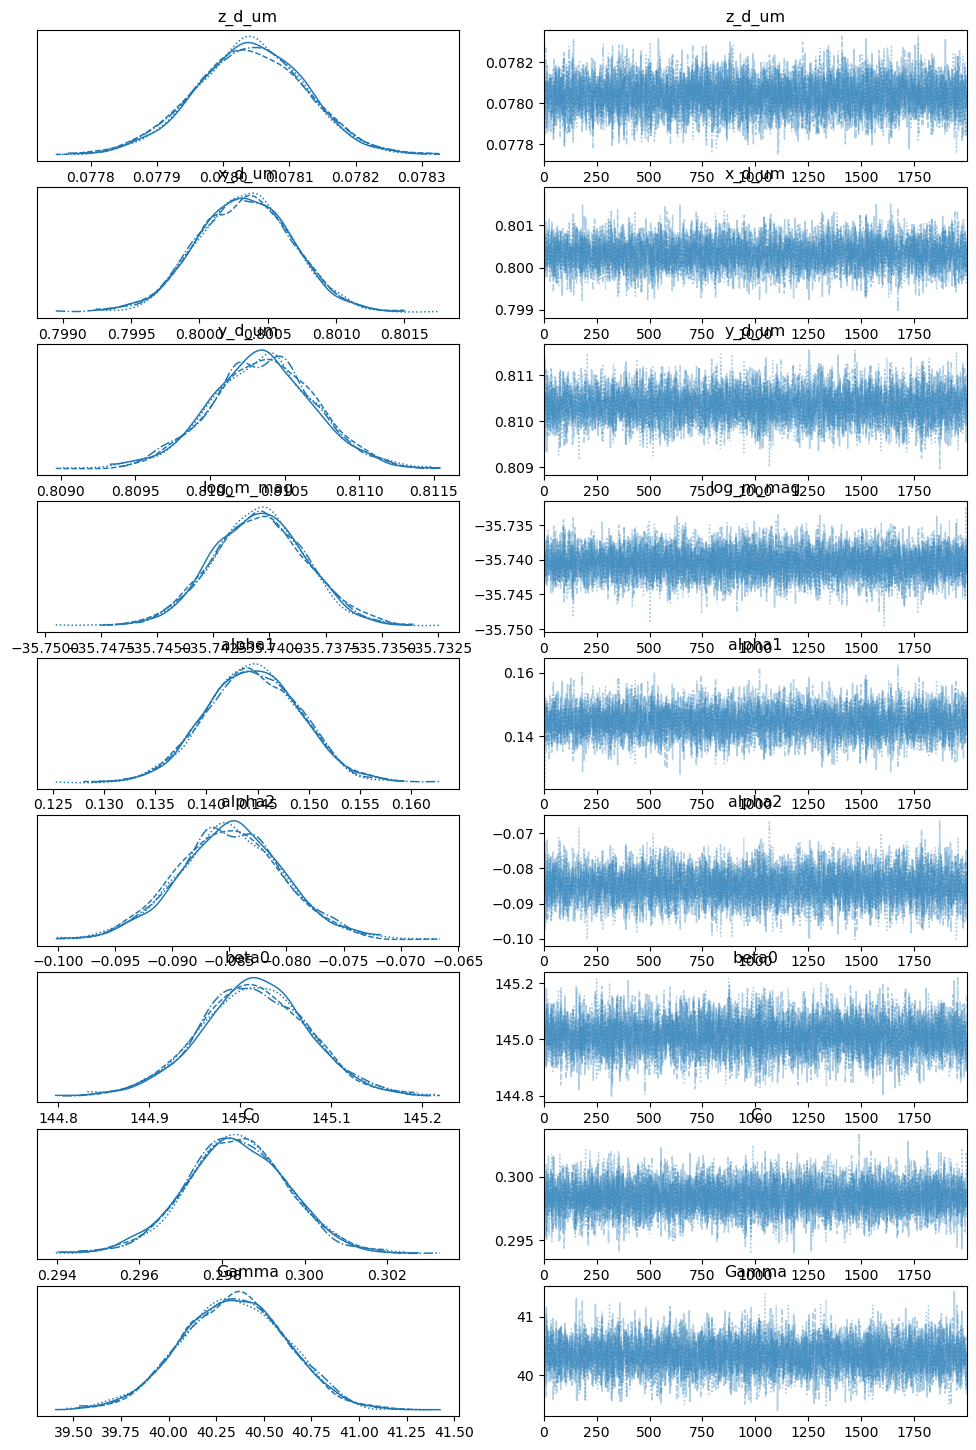

In [15]:
az.plot_trace(nv_samples,var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2", "beta0", "C", "Gamma"])

az.summary(nv_samples, var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2", "beta0", "C", "Gamma"], round_to=20)

In [16]:
# now we can recontruct desired parameters from the sampled data

# Pull sampled variables from posterior
z_d_um_samples = nv_samples.posterior["z_d_um"].values.flatten()
x_d_um_samples = nv_samples.posterior["x_d_um"].values.flatten()
y_d_um_samples = nv_samples.posterior["y_d_um"].values.flatten()
log_m_mag_samples = nv_samples.posterior["log_m_mag"].values.flatten()
alpha1_samples = nv_samples.posterior["alpha1"].values.flatten()
alpha2_samples = nv_samples.posterior["alpha2"].values.flatten()

z_d_m_samples = z_d_um_samples * 1e-6
x_d_m_samples = x_d_um_samples * 1e-6
y_d_m_samples = y_d_um_samples * 1e-6

# Reconstruct dipole magnitude
m_mag_samples = np.exp(log_m_mag_samples)

# Reconstruct dipole direction unit vector from local basis
vx_samples = u0[0] + alpha1_samples * e1[0] + alpha2_samples * e2[0]
vy_samples = u0[1] + alpha1_samples * e1[1] + alpha2_samples * e2[1]
vz_samples = u0[2] + alpha1_samples * e1[2] + alpha2_samples * e2[2]

norm_samples = np.sqrt(vx_samples**2 + vy_samples**2 + vz_samples**2)

mx_hat_samples = vx_samples / norm_samples
my_hat_samples = vy_samples / norm_samples
mz_hat_samples = vz_samples / norm_samples

# Reconstruct full dipole moment components
m_x_samples = m_mag_samples * mx_hat_samples
m_y_samples = m_mag_samples * my_hat_samples
m_z_samples = m_mag_samples * mz_hat_samples

In [17]:
print("Posterior means:")
print("z_d_um =", z_d_um_samples.mean())
print("x_d_um =", x_d_um_samples.mean())
print("y_d_um =", y_d_um_samples.mean())
print("m_mag =", m_mag_samples.mean())
print("m_x =", m_x_samples.mean())
print("m_y =", m_y_samples.mean())
print("m_z =", m_z_samples.mean())

Posterior means:
z_d_um = 0.07804018828981842
x_d_um = 0.800330205354333
y_d_um = 0.8103520901008567
m_mag = 3.0068856574995426e-16
m_x = 4.285801754383607e-17
m_y = -2.5179494977164423e-17
m_z = 2.965453844309792e-16


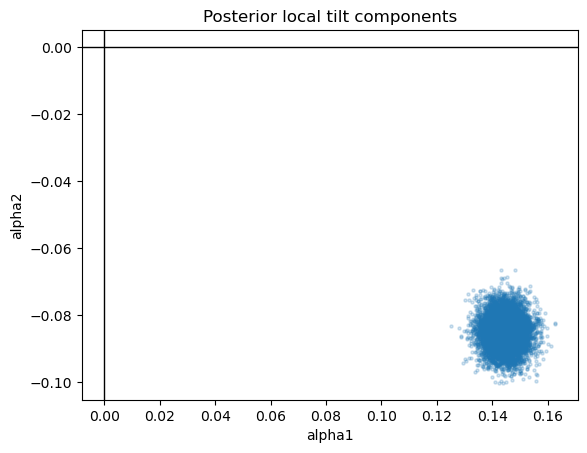

In [18]:
plt.scatter(alpha1_samples, alpha2_samples, s=5, alpha=0.2)
plt.axhline(0, color="k", lw=1)
plt.axvline(0, color="k", lw=1)
plt.xlabel("alpha1")
plt.ylabel("alpha2")
plt.title("Posterior local tilt components")
plt.show()

In [19]:
print("True dipole moment components:")
print(f"m_x_true = {m_vec_true[0]:.6e}")
print(f"m_y_true = {m_vec_true[1]:.6e}")
print(f"m_z_true = {m_vec_true[2]:.6e}")

print("\nPosterior mean dipole moment components:")
print(f"m_x_post = {m_x_samples.mean():.6e}")
print(f"m_y_post = {m_y_samples.mean():.6e}")
print(f"m_z_post = {m_z_samples.mean():.6e}")

True dipole moment components:
m_x_true = 4.436351e-17
m_y_true = -2.366054e-17
m_z_true = 2.957568e-16

Posterior mean dipole moment components:
m_x_post = 4.285802e-17
m_y_post = -2.517949e-17
m_z_post = 2.965454e-16


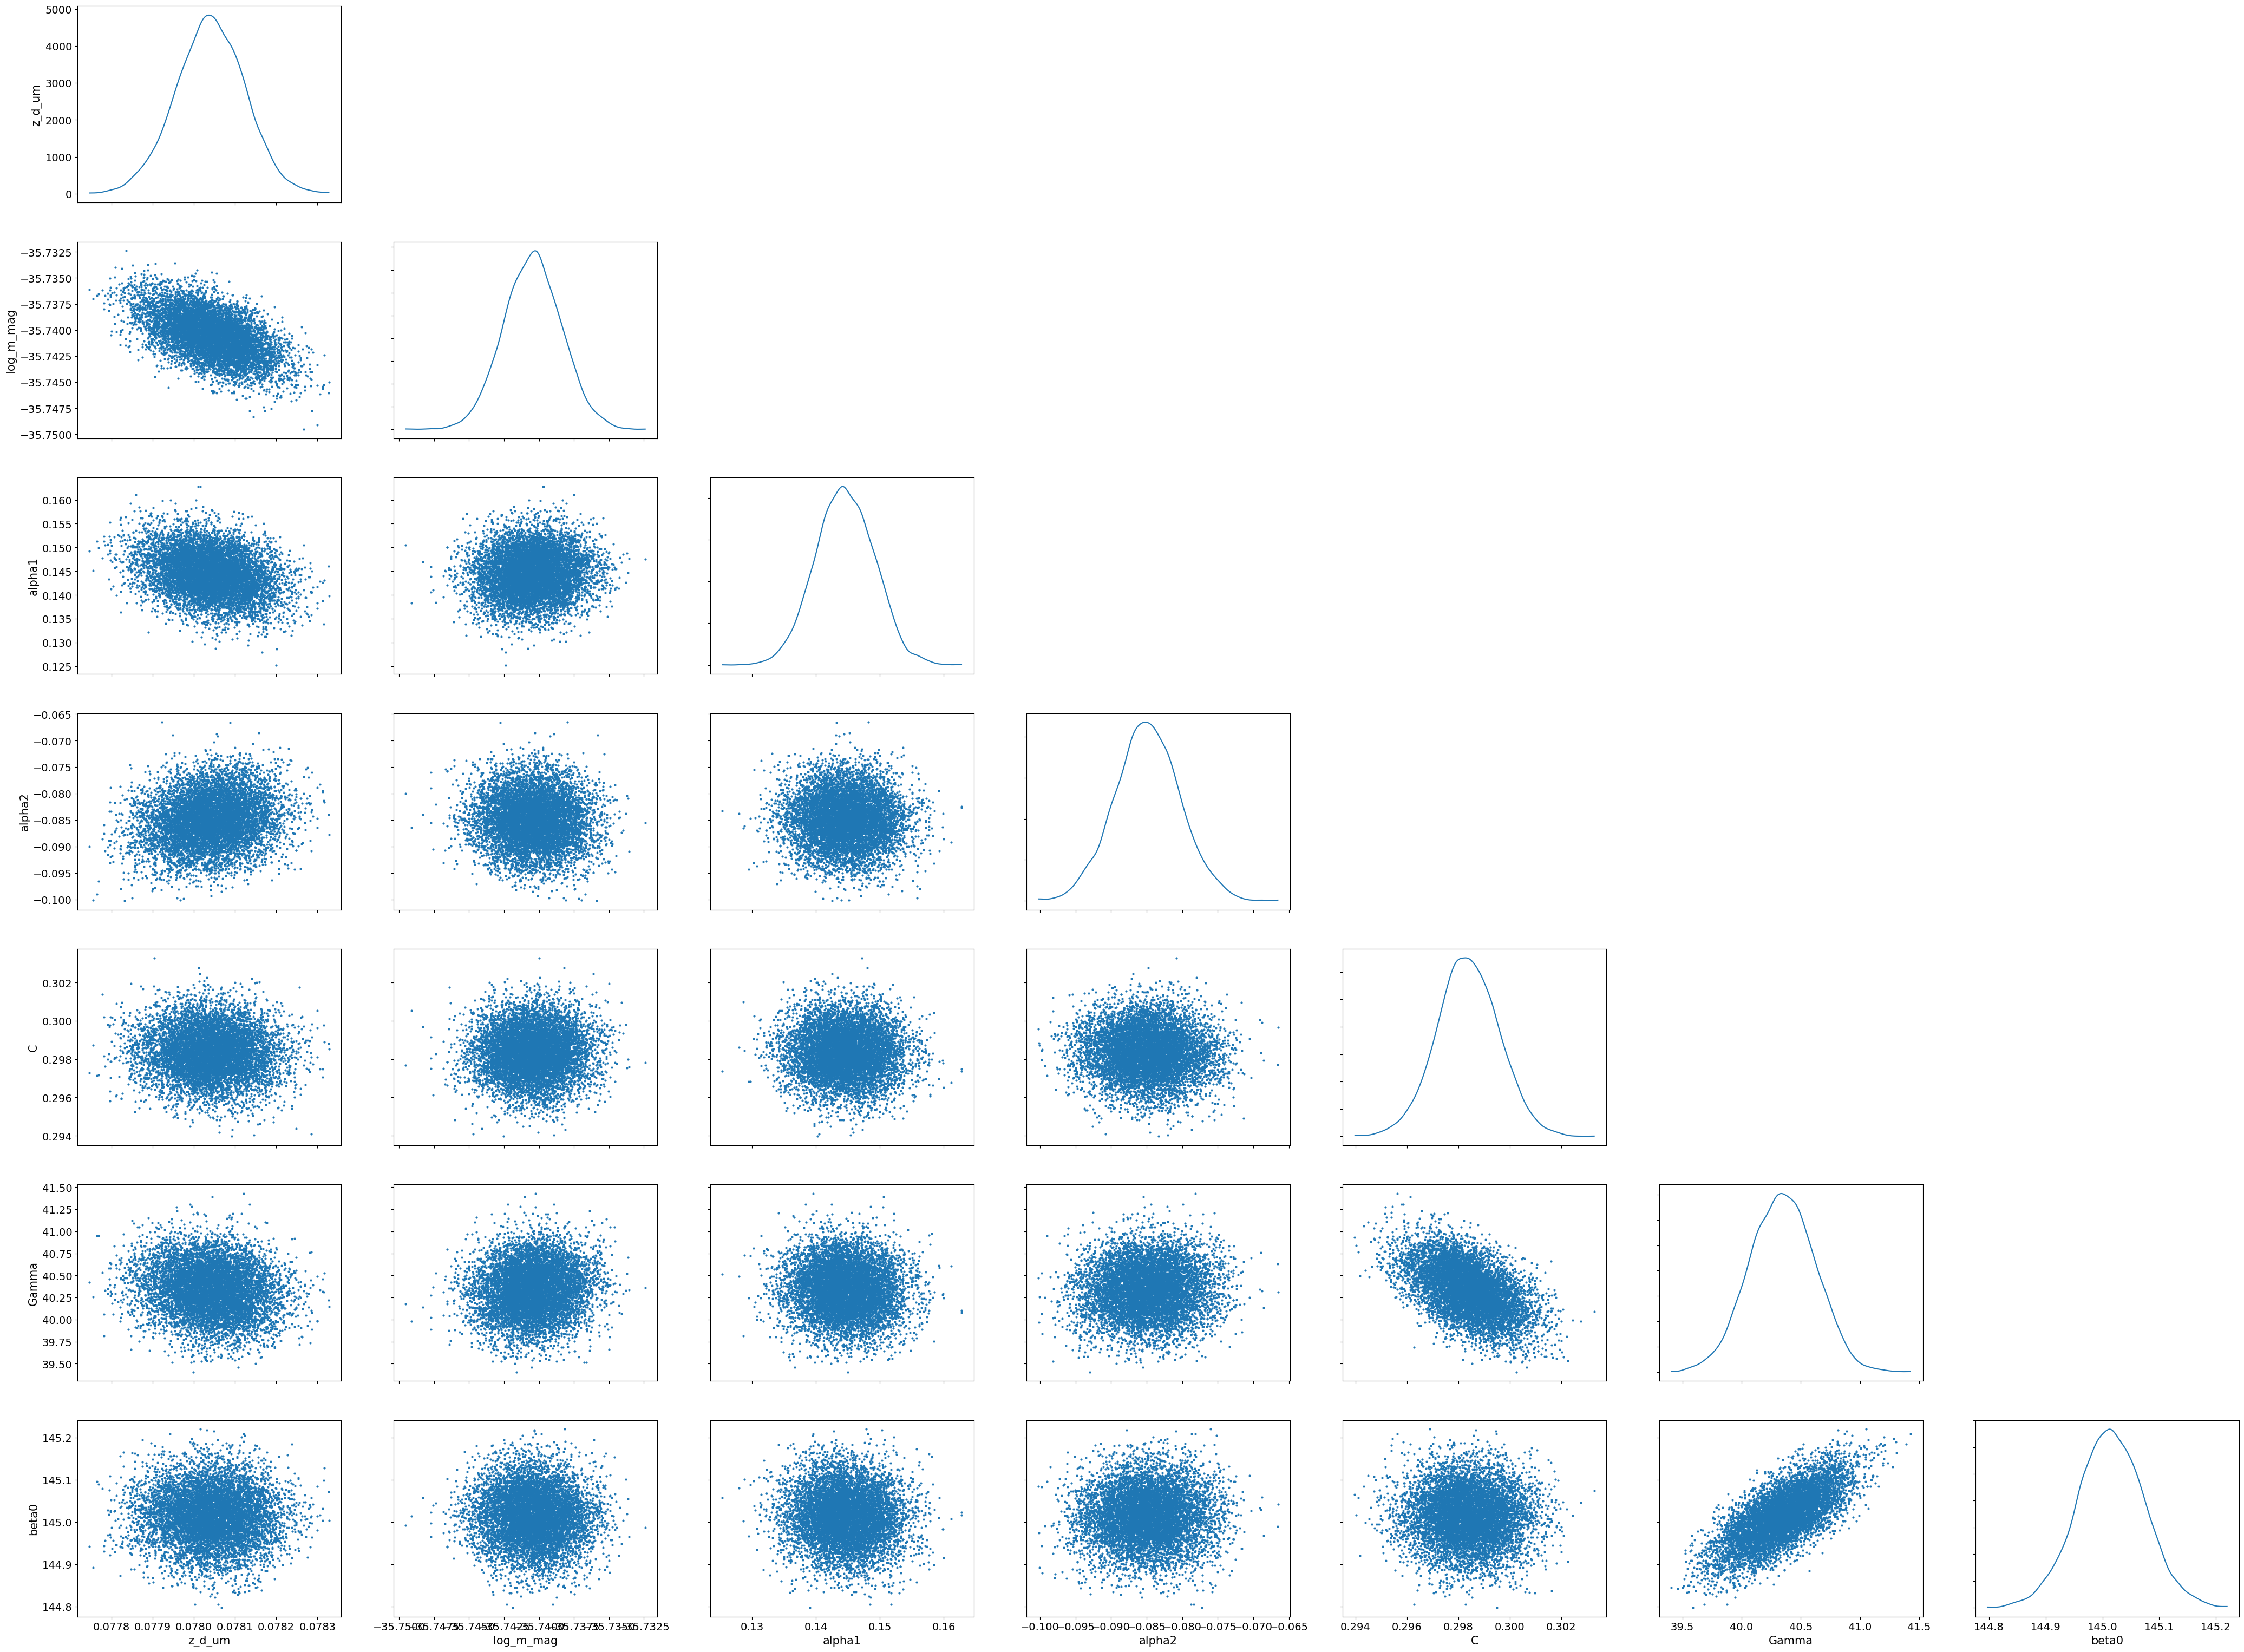

In [20]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "log_m_mag", "alpha1", "alpha2", "C", "Gamma", "beta0"],
    marginals=True
)
plt.show()

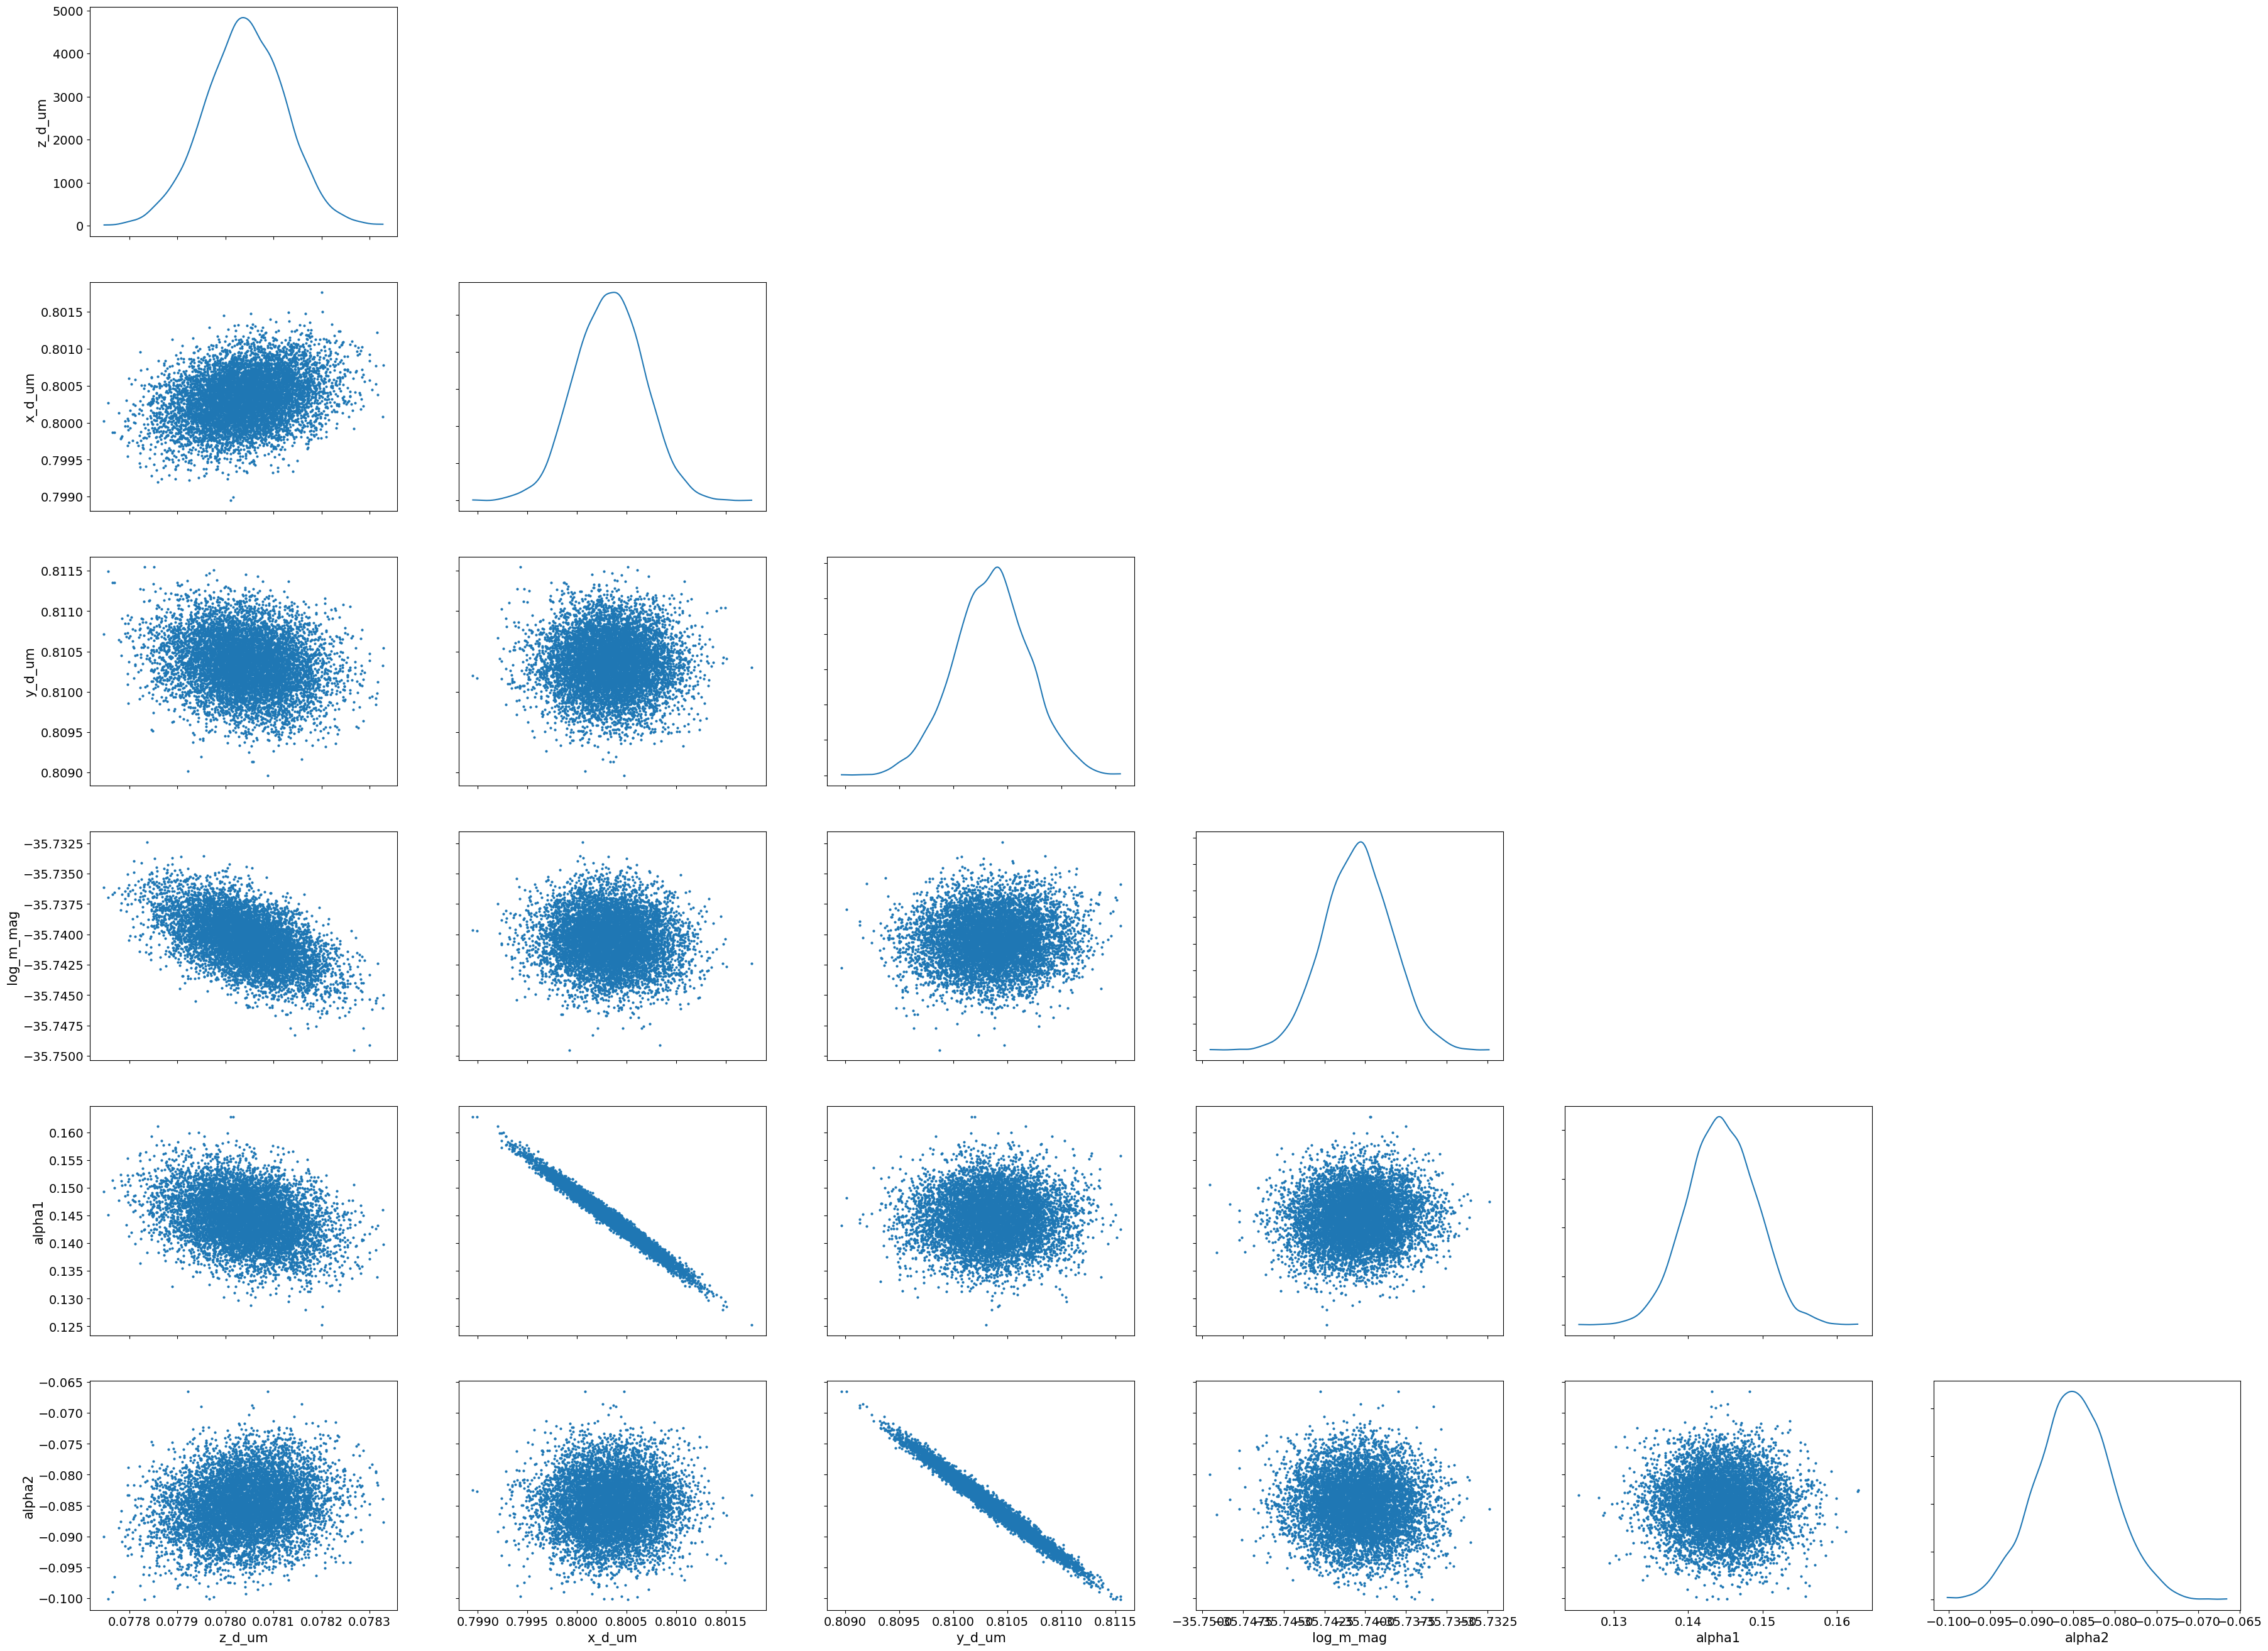

In [21]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2"],
    marginals=True
)
plt.show()

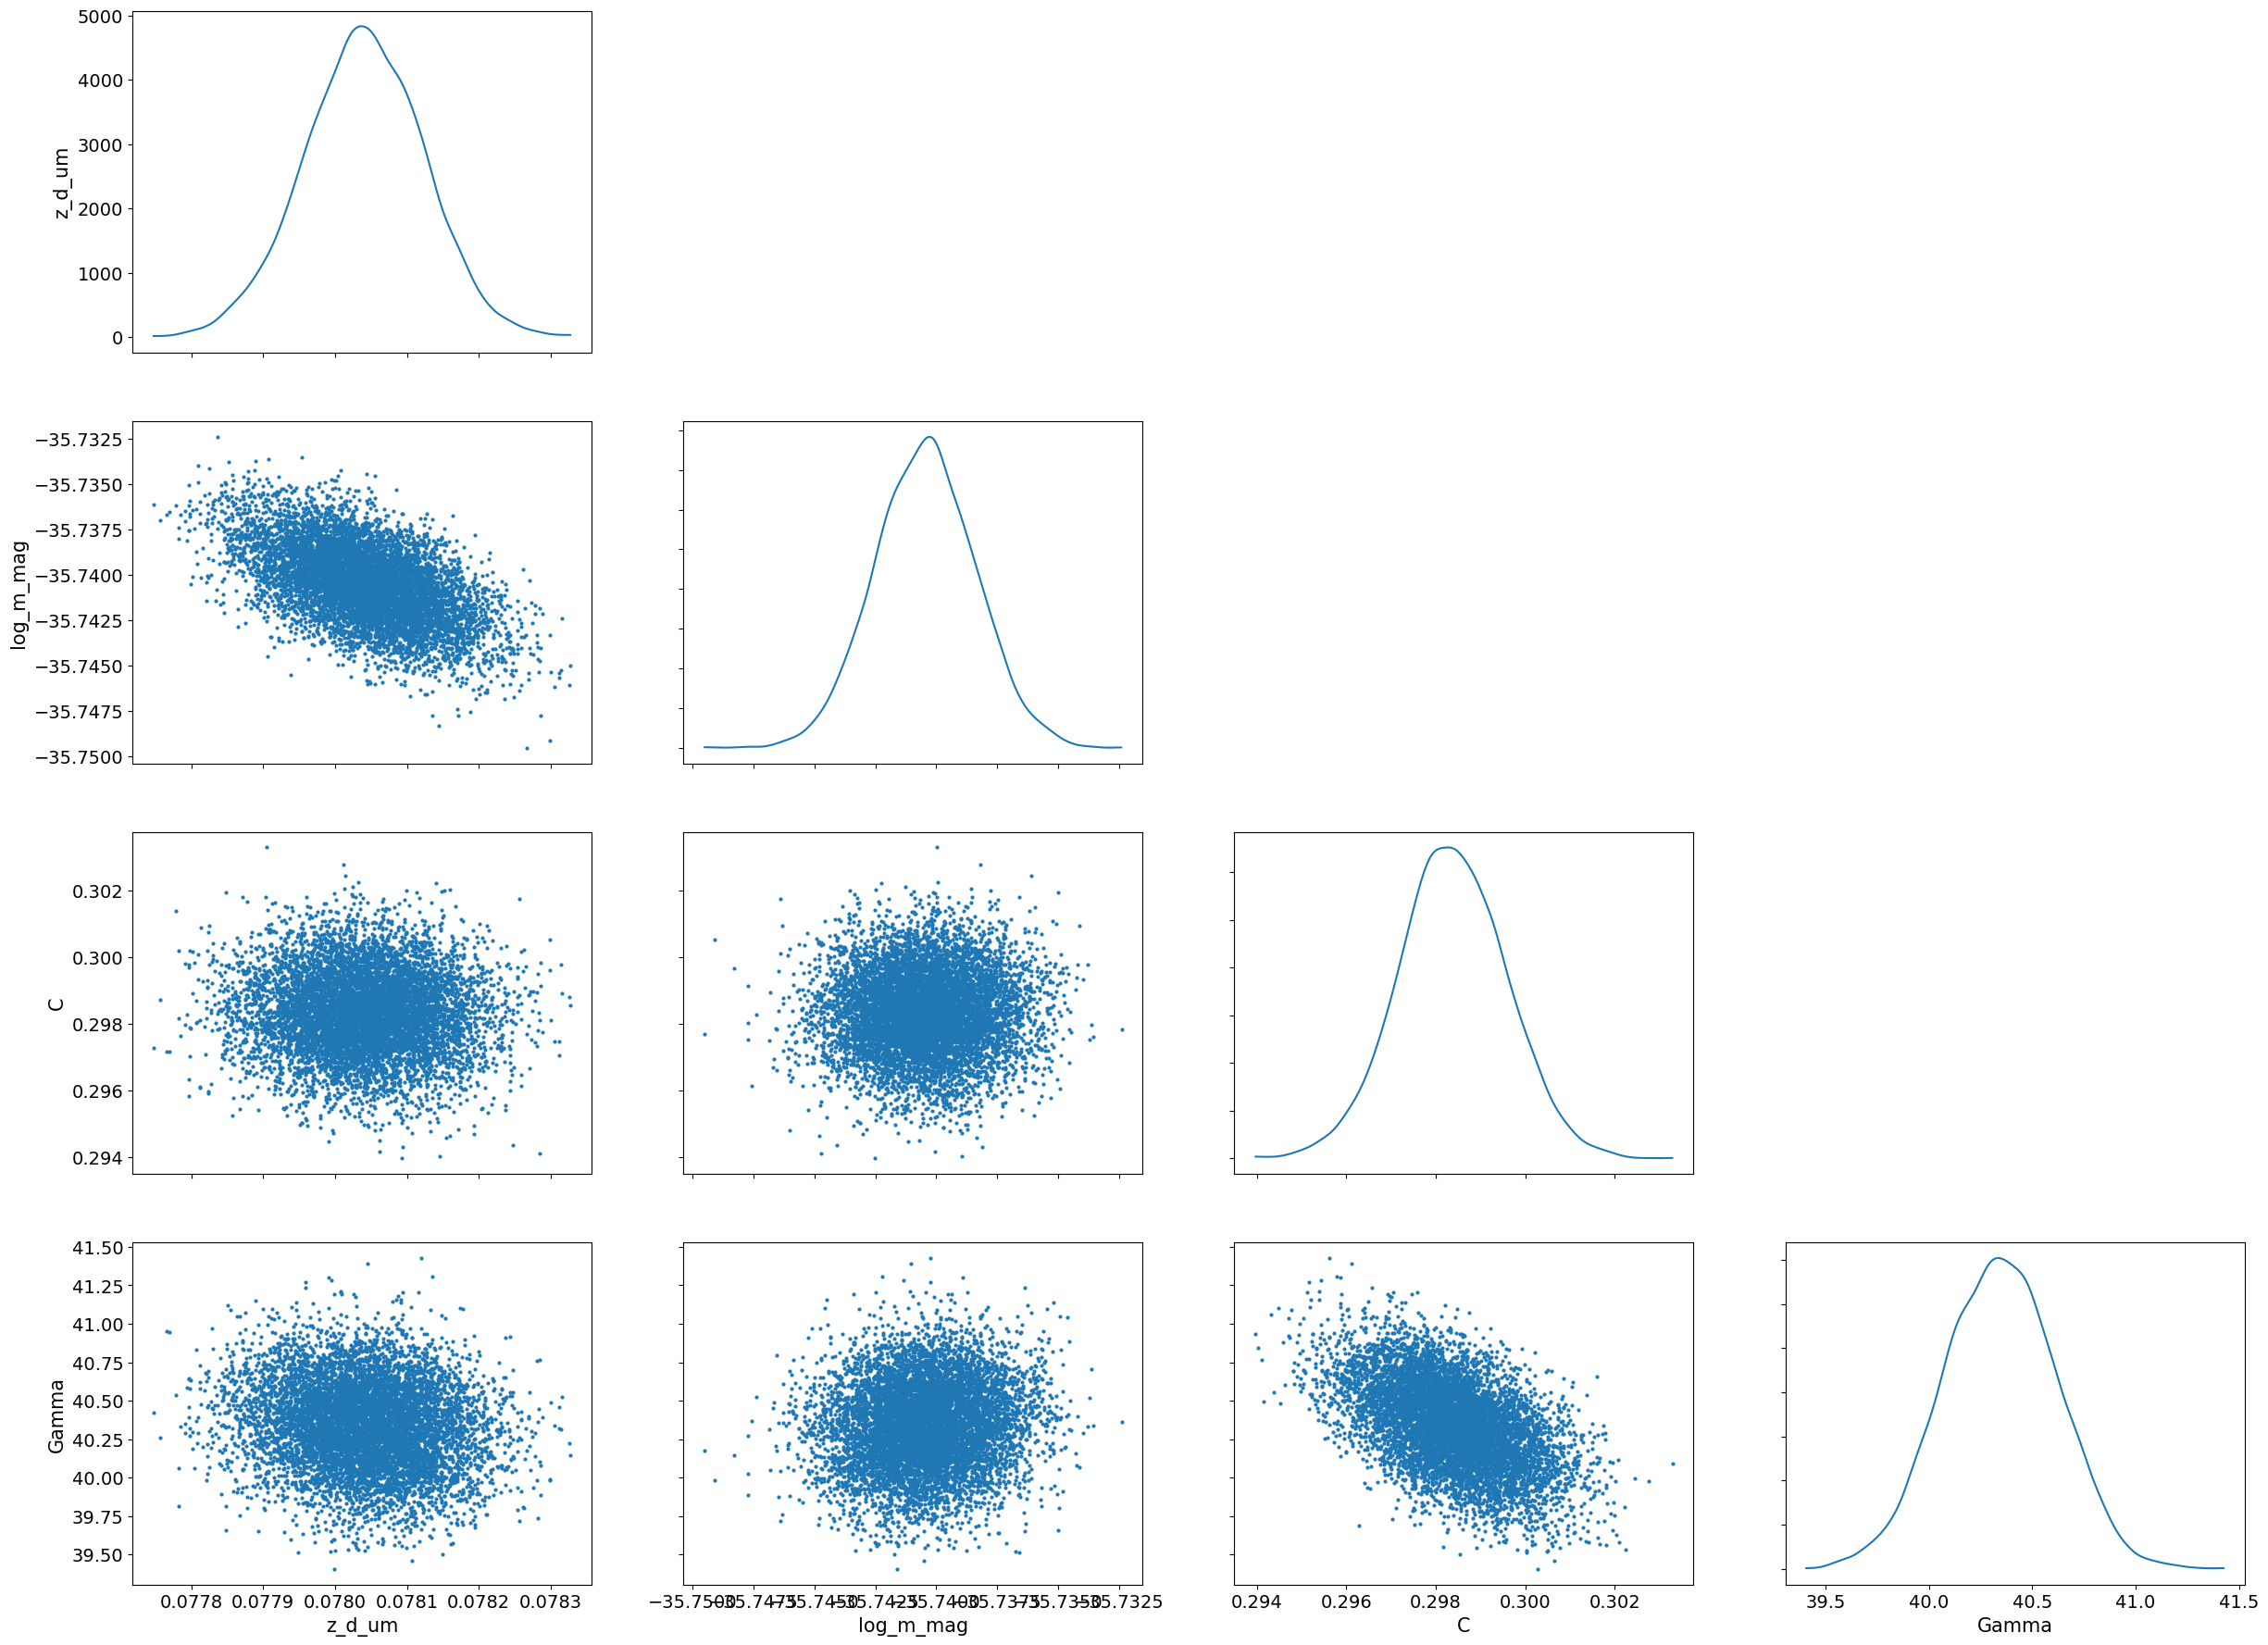

In [22]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "log_m_mag", "C", "Gamma"],
    marginals=True
)
plt.show()

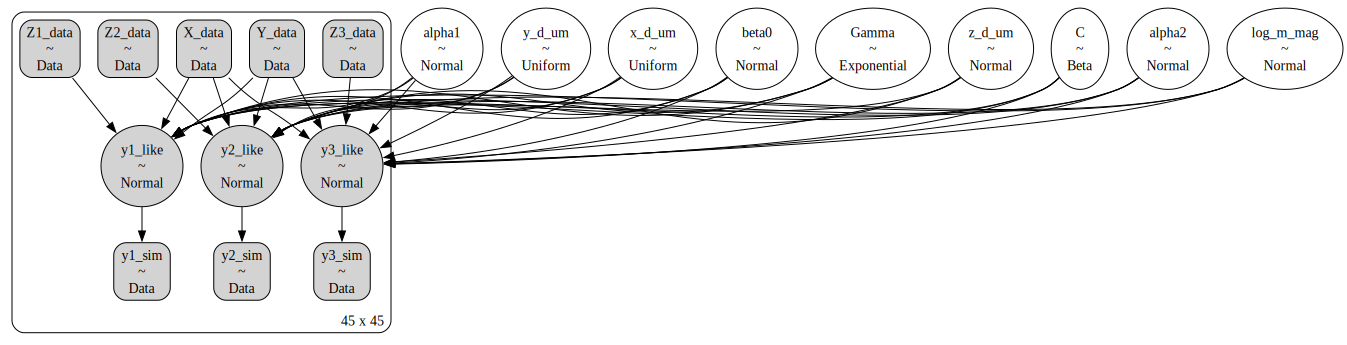

In [23]:
nv_model.to_graphviz()